# EDA — sim_daily Dataset
## MAG Energy Solutions Data Challenge 2026

**Objectif** : Explorer le dataset `sim_daily` (simulations court-terme, jour J-1 pour jour J) pour comprendre sa structure, ses distributions et identifier les signaux exploitables pour le modele de selection d'opportunites FTR.

**Approche technique** :
- DuckDB pour toutes les requetes sur les fichiers Parquet (~1GB/an)
- Extraction d'echantillons cibles uniquement pour les visualisations
- Jamais de chargement complet en pandas

**Colonnes** : SCENARIOID (3 scenarios), EID, DATETIME (horaire), PEAKID (0=OFF, 1=ON), ACTIVATIONLEVEL, 5 impacts source (WIND, SOLAR, HYDRO, NONRENEWBAL, EXTERNAL), 2 impacts explicatifs (LOAD, TRANSMISSIONOUTAGE), PSD (prix simule daily)

**Regle cle** : les donnees sont sparsifiees — seules les valeurs non-nulles sont stockees. Lignes absentes = 0.

In [1]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["figure.dpi"] = 120

DATA_PATH = "data/sim_daily/*.parquet"

con = duckdb.connect()
con.execute(f"""
    CREATE VIEW sim_daily AS
    SELECT *,
           YEAR(DATETIME)  AS YEAR,
           MONTH(DATETIME) AS MONTH,
           DAY(DATETIME)   AS DAY
    FROM read_parquet('{DATA_PATH}')
""")
print("View sim_daily created successfully.")

View sim_daily created successfully.


In [2]:
# --- Schema validation ---
print("=== SCHEMA ===")
schema = con.execute("DESCRIBE sim_daily").fetchdf()
print(schema[["column_name", "column_type"]].to_string(index=False))

# --- Row counts per year ---
print("\n=== ROW COUNTS PER YEAR ===")
counts = con.execute("""
    SELECT YEAR, COUNT(*) AS row_count
    FROM sim_daily
    GROUP BY YEAR ORDER BY YEAR
""").fetchdf()
print(counts.to_string(index=False))
print(f"\nTotal rows: {counts['row_count'].sum():,.0f}")

# --- Sanity checks ---
scenarios = con.execute("SELECT DISTINCT SCENARIOID FROM sim_daily ORDER BY 1").fetchdf()
peaks = con.execute("SELECT DISTINCT PEAKID FROM sim_daily ORDER BY 1").fetchdf()
print(f"\nSCENARIOIDs: {scenarios['SCENARIOID'].tolist()}")
print(f"PEAKIDs:     {peaks['PEAKID'].tolist()}")

=== SCHEMA ===
             column_name  column_type
              SCENARIOID      TINYINT
                     EID     SMALLINT
                DATETIME TIMESTAMP_NS
                  PEAKID      TINYINT
         ACTIVATIONLEVEL        FLOAT
              WINDIMPACT        FLOAT
             SOLARIMPACT        FLOAT
             HYDROIMPACT        FLOAT
       NONRENEWBALIMPACT        FLOAT
          EXTERNALIMPACT        FLOAT
              LOADIMPACT        FLOAT
TRANSMISSIONOUTAGEIMPACT        FLOAT
                     PSD        FLOAT
                    YEAR       BIGINT
                   MONTH       BIGINT
                     DAY       BIGINT

=== ROW COUNTS PER YEAR ===
 YEAR  row_count
 2020  123513870
 2021      15522

Total rows: 123,529,392

SCENARIOIDs: [1, 2, 3]
PEAKIDs:     [0, 1]


## 2. Dimensions
Nombre d'EIDs distincts par annee, stabilite inter-annees, et distribution des lignes par (SCENARIOID, PEAKID, mois).

In [3]:
# --- Distinct EIDs per year ---
print("=== EIDs DISTINCTS PAR ANNEE ===")
eid_per_year = con.execute("""
    SELECT YEAR, COUNT(DISTINCT EID) AS n_eids
    FROM sim_daily
    GROUP BY YEAR ORDER BY YEAR
""").fetchdf()
print(eid_per_year.to_string(index=False))

# --- EID stability across years ---
print("\n=== STABILITE DES EIDs ===")
eid_years = con.execute("""
    SELECT EID, COUNT(DISTINCT YEAR) AS n_years,
           LIST(DISTINCT YEAR ORDER BY YEAR) AS years_present
    FROM sim_daily
    GROUP BY EID
""").fetchdf()

total_years = eid_years["n_years"].max()
stable = (eid_years["n_years"] == total_years).sum()
partial = (eid_years["n_years"] < total_years).sum()
print(f"EIDs presents dans les {total_years} annee(s): {stable}")
print(f"EIDs dans un sous-ensemble d'annees: {partial}")

if partial > 0:
    print("\nExemples d'EIDs partiels:")
    print(eid_years[eid_years["n_years"] < total_years]
          .sort_values("n_years").head(20).to_string(index=False))

=== EIDs DISTINCTS PAR ANNEE ===
 YEAR  n_eids
 2020    5386
 2021    5174

=== STABILITE DES EIDs ===
EIDs presents dans les 2 annee(s): 5174
EIDs dans un sous-ensemble d'annees: 212

Exemples d'EIDs partiels:
 EID  n_years years_present
 719        1        [2020]
4575        1        [2020]
5373        1        [2020]
1770        1        [2020]
6365        1        [2020]
1263        1        [2020]
 789        1        [2020]
2211        1        [2020]
1728        1        [2020]
6375        1        [2020]
2078        1        [2020]
2080        1        [2020]
4767        1        [2020]
5936        1        [2020]
6149        1        [2020]
 918        1        [2020]
1016        1        [2020]
 358        1        [2020]
5649        1        [2020]
2183        1        [2020]


In [4]:
# --- Cross-tab: rows by (SCENARIOID, PEAKID, MONTH) ---
print("=== LIGNES PAR (YEAR, MONTH, SCENARIOID, PEAKID) ===")
cross = con.execute("""
    SELECT YEAR, MONTH, SCENARIOID, PEAKID, COUNT(*) AS n_rows
    FROM sim_daily
    GROUP BY YEAR, MONTH, SCENARIOID, PEAKID
    ORDER BY YEAR, MONTH, SCENARIOID, PEAKID
""").fetchdf()

for yr in sorted(cross["YEAR"].unique()):
    sub = cross[cross["YEAR"] == yr]
    pivot = sub.pivot_table(
        index=["MONTH", "PEAKID"], columns="SCENARIOID",
        values="n_rows", aggfunc="sum"
    )
    pivot.columns = [f"Scenario_{c}" for c in pivot.columns]
    print(f"\n--- {yr} ---")
    print(pivot.to_string())

# Verification: all (SCENARIOID, PEAKID) combos have same row count per month?
print("\n=== EQUILIBRAGE ===")
check = cross.groupby(["YEAR", "MONTH"])["n_rows"].nunique()
if (check == 1).all():
    print("Toutes les combinaisons (SCENARIOID, PEAKID) ont le meme nombre de lignes par mois.")
else:
    print("ATTENTION: desequilibre detecte!")
    print(check[check > 1])

=== LIGNES PAR (YEAR, MONTH, SCENARIOID, PEAKID) ===

--- 2020 ---
              Scenario_1  Scenario_2  Scenario_3
MONTH PEAKID                                    
1     0          1120886     1120886     1120886
      1          2250848     2250848     2250848
2     0          1052816     1052816     1052816
      1          2105632     2105632     2105632
3     0          1125424     1125424     1125424
      1          2250848     2250848     2250848
4     0          1094510     1094510     1094510
      1          2189216     2189216     2189216
5     0          1149728     1149728     1149728
      1          2299456     2299456     2299456
6     0          1112640     1112640     1112640
      1          2225280     2225280     2225280
7     0          1149728     1149728     1149728
      1          2299456     2299456     2299456
8     0          1149728     1149728     1149728
      1          2299456     2299456     2299456
9     0          1112640     1112640     1112640
  

## 3. Couverture temporelle

Verification des jours couverts par mois et de la convention Hour Ending (HE) : le timestamp indique la **fin** de l'heure, donc la derniere heure du jour 7 a pour timestamp `YYYY-MM-08 00:00:00`.

On confirme aussi que les sims daily couvrent bien les jours du mois courant (pas M+1).

In [5]:
# --- Days covered per month ---
print("=== COUVERTURE TEMPORELLE PAR MOIS ===")
coverage = con.execute("""
    SELECT YEAR, MONTH,
           MIN(DATETIME)          AS first_ts,
           MAX(DATETIME)          AS last_ts,
           COUNT(DISTINCT CAST(DATETIME AS DATE)) AS distinct_dates,
           MIN(DAY) AS min_day, MAX(DAY) AS max_day
    FROM sim_daily
    GROUP BY YEAR, MONTH
    ORDER BY YEAR, MONTH
""").fetchdf()
print(coverage.to_string(index=False))

# Check: does max_day ever exceed expected month length + 1 (HE overflow)?
print("\n=== MAX DAY PAR MOIS (attendu: dernier jour du mois +1 pour HE) ===")
print(coverage[["YEAR", "MONTH", "min_day", "max_day"]].to_string(index=False))

=== COUVERTURE TEMPORELLE PAR MOIS ===
 YEAR  MONTH            first_ts             last_ts  distinct_dates  min_day  max_day
 2020      1 2020-01-01 01:00:00 2020-01-31 23:00:00              31        1       31
 2020      2 2020-02-01 00:00:00 2020-02-29 23:00:00              29        1       29
 2020      3 2020-03-01 00:00:00 2020-03-31 23:00:00              31        1       31
 2020      4 2020-04-01 00:00:00 2020-04-30 23:00:00              30        1       30
 2020      5 2020-05-01 00:00:00 2020-05-31 23:00:00              31        1       31
 2020      6 2020-06-01 00:00:00 2020-06-30 23:00:00              30        1       30
 2020      7 2020-07-01 00:00:00 2020-07-31 23:00:00              31        1       31
 2020      8 2020-08-01 00:00:00 2020-08-31 23:00:00              31        1       31
 2020      9 2020-09-01 00:00:00 2020-09-30 23:00:00              30        1       30
 2020     10 2020-10-01 00:00:00 2020-10-31 23:00:00              31        1       31
 202

In [6]:
# --- HE convention verification ---
# Inspect all timestamps for one specific day (Jan 7, 2020) for one EID/scenario
print("=== VERIFICATION CONVENTION HE — Jour 7, Janvier 2020 ===")
sample_eid = con.execute("SELECT MIN(EID) AS eid FROM sim_daily").fetchone()[0]

he_check = con.execute(f"""
    SELECT DISTINCT DATETIME, DAY, PEAKID
    FROM sim_daily
    WHERE YEAR = 2020 AND MONTH = 1
      AND EID = {sample_eid} AND SCENARIOID = 1
      AND DATETIME >= '2020-01-07 00:00:00'
      AND DATETIME <= '2020-01-08 01:00:00'
    ORDER BY DATETIME
""").fetchdf()
print(f"EID={sample_eid}, Scenario 1 — timestamps autour du 7 janvier:")
print(he_check.to_string(index=False))

print("\nSi le dernier timestamp est 2020-01-08 00:00:00, la convention HE est confirmee.")
print("(Le timestamp marque la FIN de l'heure, donc 08 00:00 = derniere heure du jour 7)")

=== VERIFICATION CONVENTION HE — Jour 7, Janvier 2020 ===
EID=2, Scenario 1 — timestamps autour du 7 janvier:
           DATETIME  DAY  PEAKID
2020-01-07 00:00:00    7       0
2020-01-07 01:00:00    7       0
2020-01-07 02:00:00    7       0
2020-01-07 03:00:00    7       0
2020-01-07 04:00:00    7       0
2020-01-07 05:00:00    7       0
2020-01-07 06:00:00    7       0
2020-01-07 07:00:00    7       1
2020-01-07 08:00:00    7       1
2020-01-07 09:00:00    7       1
2020-01-07 10:00:00    7       1
2020-01-07 11:00:00    7       1
2020-01-07 12:00:00    7       1
2020-01-07 13:00:00    7       1
2020-01-07 14:00:00    7       1
2020-01-07 15:00:00    7       1
2020-01-07 16:00:00    7       1
2020-01-07 17:00:00    7       1
2020-01-07 18:00:00    7       1
2020-01-07 19:00:00    7       1
2020-01-07 20:00:00    7       1
2020-01-07 21:00:00    7       1
2020-01-07 22:00:00    7       1
2020-01-07 23:00:00    7       0
2020-01-08 00:00:00    8       0
2020-01-08 01:00:00    8       0

## 4. Analyse de sparsity

Les donnees sont **sparsifiees** : seules les lignes avec au moins une valeur non-nulle sont stockees. On mesure ici le % de zeros **parmi les lignes presentes** pour chaque variable.

In [7]:
# --- Percent zeros per variable ---
VARS = [
    "ACTIVATIONLEVEL", "WINDIMPACT", "SOLARIMPACT", "HYDROIMPACT",
    "NONRENEWBALIMPACT", "EXTERNALIMPACT", "LOADIMPACT",
    "TRANSMISSIONOUTAGEIMPACT", "PSD"
]

agg_parts = []
for v in VARS:
    agg_parts.append(f"SUM(CASE WHEN {v} = 0 THEN 1 ELSE 0 END) AS {v}_zeros")
agg_parts.append("COUNT(*) AS total")

raw = con.execute(f"SELECT {', '.join(agg_parts)} FROM sim_daily").fetchdf()

rows = []
total = raw["total"].iloc[0]
for v in VARS:
    zeros = raw[f"{v}_zeros"].iloc[0]
    rows.append({
        "variable": v,
        "zeros": int(zeros),
        "non_zeros": int(total - zeros),
        "pct_zero": round(100 * zeros / total, 2)
    })
sparsity = pd.DataFrame(rows).sort_values("pct_zero", ascending=False)
print("=== SPARSITY (% de zeros parmi les lignes stockees) ===")
print(sparsity.to_string(index=False))

=== SPARSITY (% de zeros parmi les lignes stockees) ===
                variable     zeros  non_zeros  pct_zero
                     PSD 123270422     258970     99.79
             SOLARIMPACT 105119043   18410349     85.10
             HYDROIMPACT  87001660   36527732     70.43
TRANSMISSIONOUTAGEIMPACT  86828171   36701221     70.29
          EXTERNALIMPACT  86750628   36778764     70.23
       NONRENEWBALIMPACT  86220961   37308431     69.80
              WINDIMPACT  85856644   37672748     69.50
              LOADIMPACT  85348622   38180770     69.09
         ACTIVATIONLEVEL  83913766   39615626     67.93


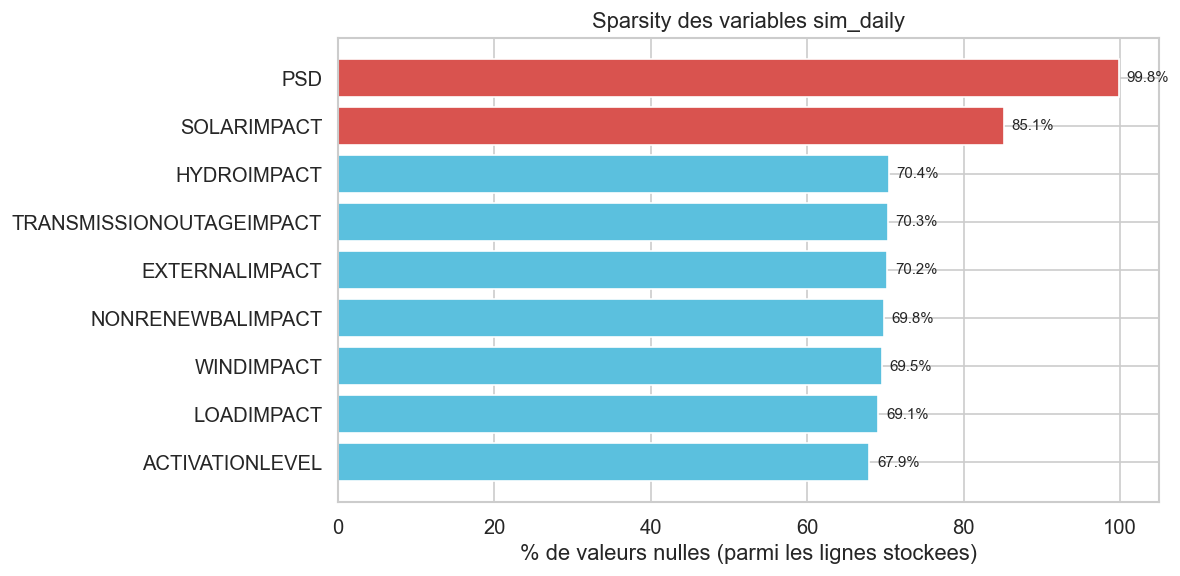

In [8]:
# --- Sparsity bar chart ---
fig, ax = plt.subplots(figsize=(10, 5))
colors = ["#d9534f" if pct > 80 else "#5bc0de" if pct > 50 else "#5cb85c"
          for pct in sparsity["pct_zero"]]
ax.barh(sparsity["variable"], sparsity["pct_zero"], color=colors, edgecolor="white")
ax.set_xlabel("% de valeurs nulles (parmi les lignes stockees)")
ax.set_title("Sparsity des variables sim_daily")
ax.set_xlim(0, 105)
ax.invert_yaxis()
for i, (v, pct) in enumerate(zip(sparsity["variable"], sparsity["pct_zero"])):
    ax.text(pct + 1, i, f"{pct:.1f}%", va="center", fontsize=9)
plt.tight_layout()
plt.show()

## 5. Distributions des variables cles

Statistiques descriptives calculees sur l'ensemble du dataset via DuckDB, puis histogrammes sur un echantillon de 100k lignes.

In [9]:
# --- Summary statistics (full dataset, computed in DuckDB) ---
union_parts = []
for v in VARS:
    union_parts.append(f"""
        SELECT '{v}' AS variable,
               MIN({v}) AS min_val,
               APPROX_QUANTILE({v}, 0.25) AS q25,
               MEDIAN({v}) AS median,
               AVG({v}) AS mean,
               APPROX_QUANTILE({v}, 0.75) AS q75,
               MAX({v}) AS max_val,
               STDDEV({v}) AS std
        FROM sim_daily
    """)
summary = con.execute(" UNION ALL ".join(union_parts)).fetchdf()
summary.columns = ["variable", "min", "q25", "median", "mean", "q75", "max", "std"]
print("=== STATISTIQUES DESCRIPTIVES (dataset complet) ===")
print(summary.to_string(index=False, float_format="%.4f"))

=== STATISTIQUES DESCRIPTIVES (dataset complet) ===
                variable           min    q25  median    mean    q75         max     std
         ACTIVATIONLEVEL        0.0000 0.0000  0.0000  8.1397 7.6450    175.9981 16.3606
              WINDIMPACT  -204386.3281 0.0000  0.0000  3.2883 0.0006 173142.6719 32.0136
             SOLARIMPACT    -8372.3516 0.0000  0.0000  0.0106 0.0000  28212.3262  3.8168
             HYDROIMPACT -1022559.8750 0.0000  0.0000  0.3364 0.0000 111559.8125 94.9717
       NONRENEWBALIMPACT  -239106.6719 0.0000  0.0000  3.5198 0.0000 546873.0000 59.2501
          EXTERNALIMPACT   -76388.0312 0.0000  0.0000  0.1458 0.0000 561089.2500 53.5884
              LOADIMPACT  -139055.3594 0.0000  0.0000  0.2067 0.0000  33719.1797 14.5363
TRANSMISSIONOUTAGEIMPACT  -122626.0938 0.0000  0.0000  0.3105 0.0000  14364.0850 14.9209
                     PSD    -1728.2700 0.0000  0.0000 -0.1365 0.0000    996.5395  5.4725


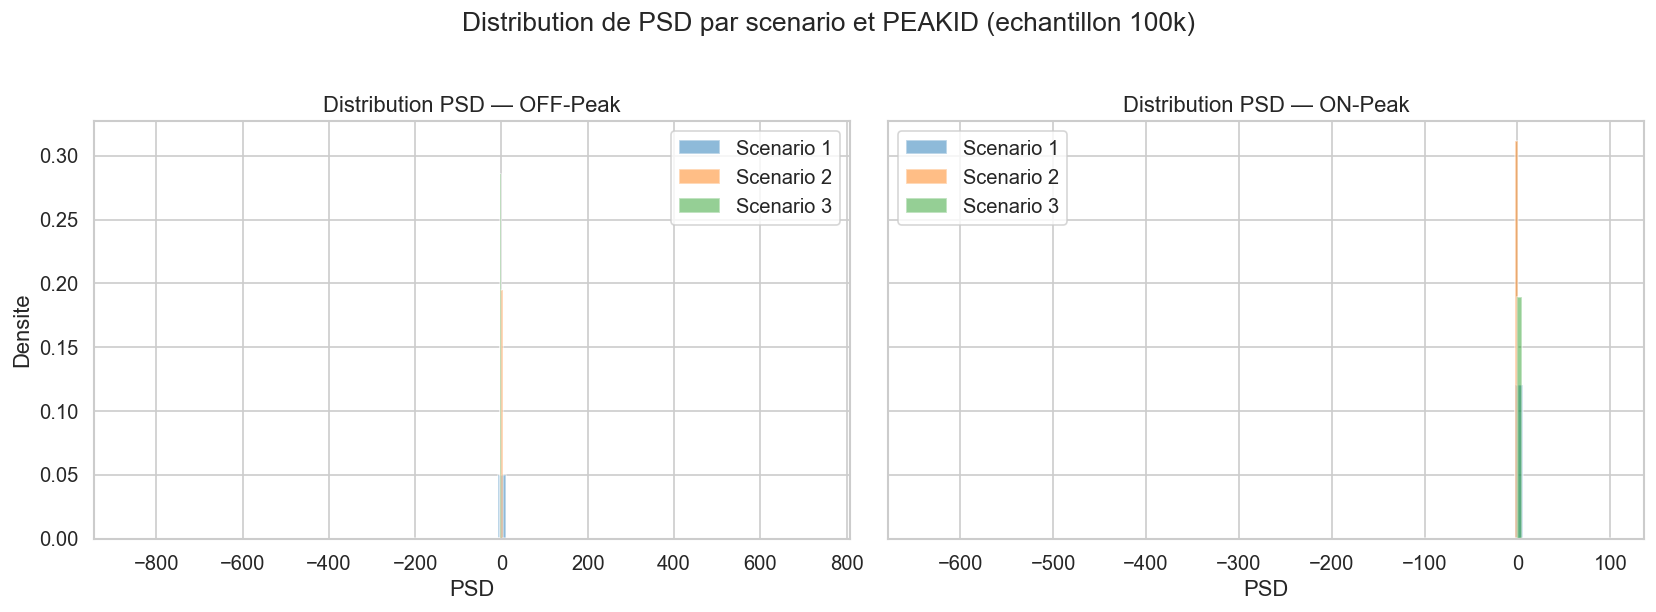

In [10]:
# --- PSD histograms by scenario and PEAKID ---
sample_psd = con.execute("""
    SELECT SCENARIOID, PEAKID, PSD
    FROM sim_daily USING SAMPLE 100000
""").fetchdf()

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
peak_labels = {0: "OFF-Peak", 1: "ON-Peak"}
colors = {1: "#1f77b4", 2: "#ff7f0e", 3: "#2ca02c"}

for i, peak in enumerate([0, 1]):
    ax = axes[i]
    sub = sample_psd[sample_psd["PEAKID"] == peak]
    for sc in [1, 2, 3]:
        vals = sub[sub["SCENARIOID"] == sc]["PSD"]
        ax.hist(vals, bins=80, alpha=0.5, density=True,
                label=f"Scenario {sc}", color=colors[sc])
    ax.set_title(f"Distribution PSD — {peak_labels[peak]}")
    ax.set_xlabel("PSD")
    ax.legend()
axes[0].set_ylabel("Densite")
plt.suptitle("Distribution de PSD par scenario et PEAKID (echantillon 100k)", y=1.02)
plt.tight_layout()
plt.show()

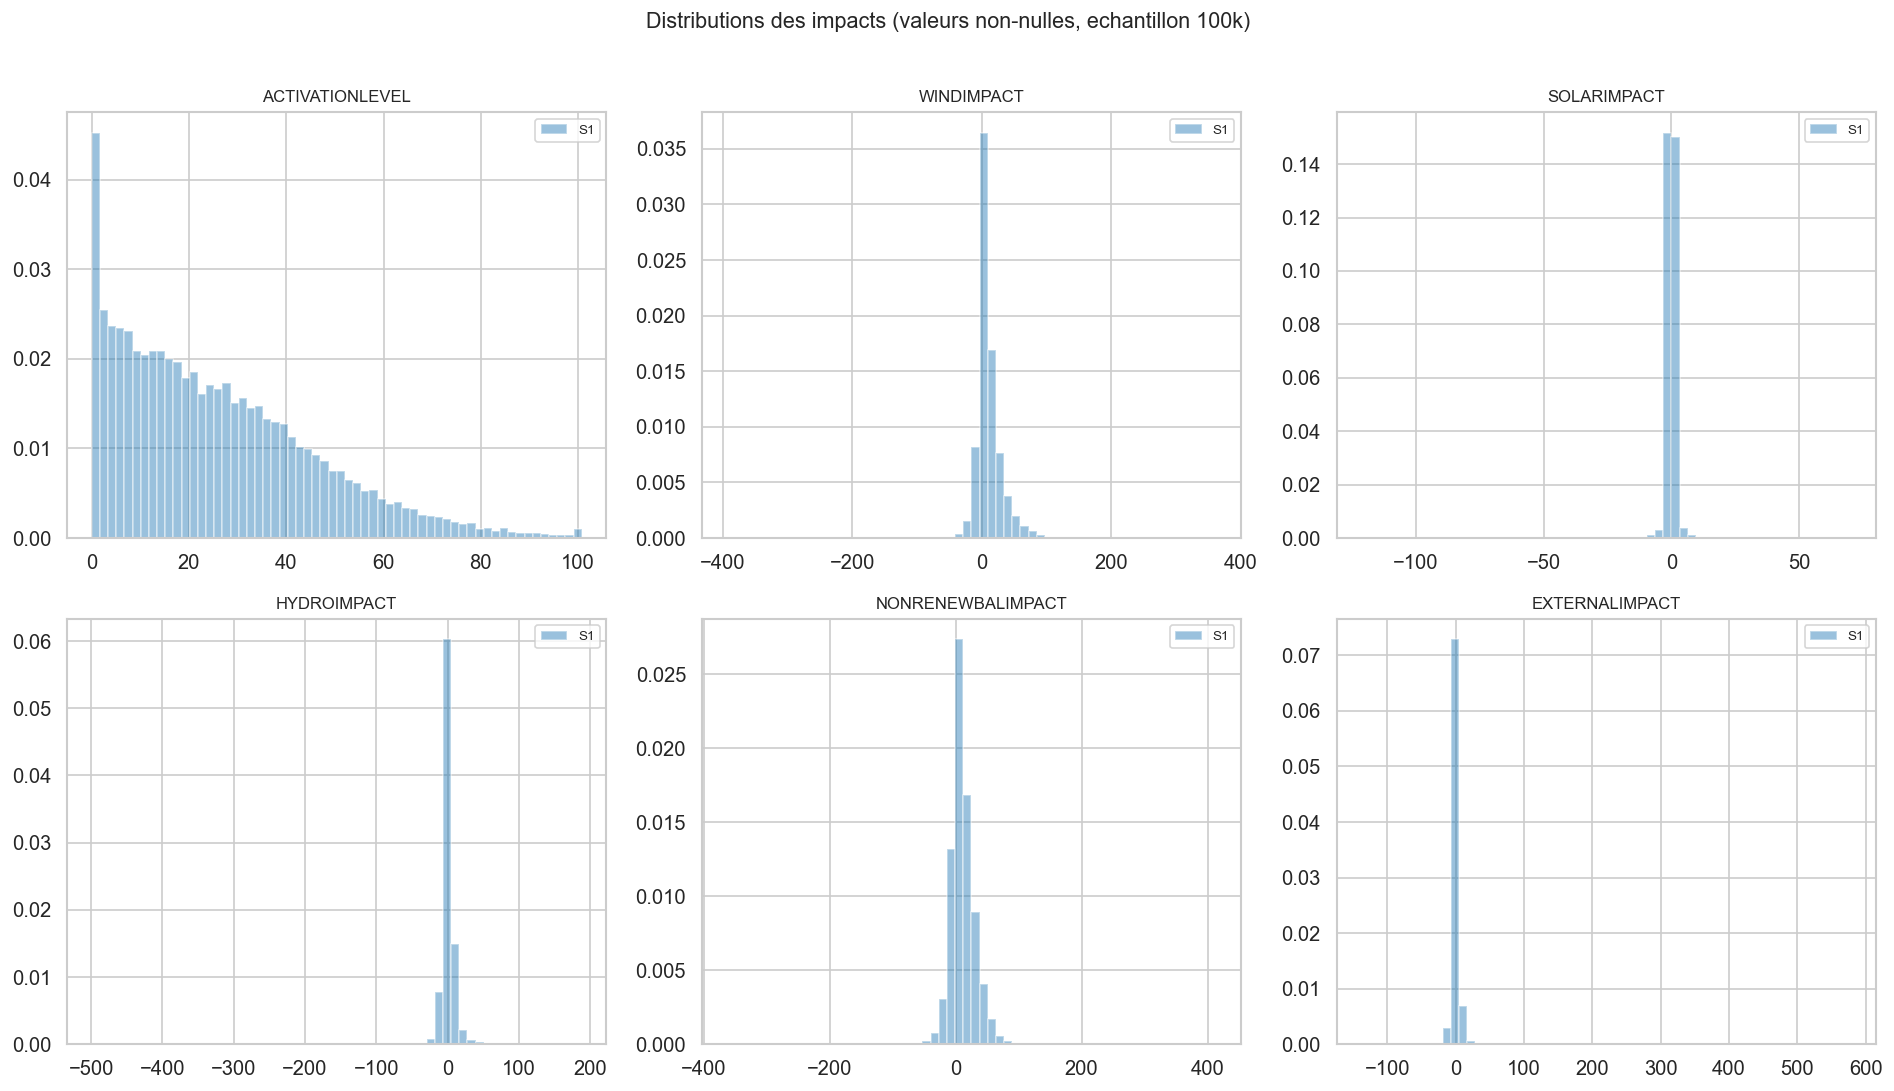

In [11]:
# --- Impact variable histograms (grid) ---
impact_vars = ["ACTIVATIONLEVEL", "WINDIMPACT", "SOLARIMPACT",
               "HYDROIMPACT", "NONRENEWBALIMPACT", "EXTERNALIMPACT"]

sample_impacts = con.execute(f"""
    SELECT SCENARIOID, {', '.join(impact_vars)}
    FROM sim_daily USING SAMPLE 100000
""").fetchdf()

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for idx, var in enumerate(impact_vars):
    ax = axes[idx // 3, idx % 3]
    for sc in [1, 2, 3]:
        vals = sample_impacts[sample_impacts["SCENARIOID"] == sc][var]
        vals_nz = vals[vals != 0]
        if len(vals_nz) > 0:
            ax.hist(vals_nz, bins=60, alpha=0.45, density=True,
                    label=f"S{sc}", color=colors[sc])
    ax.set_title(var, fontsize=10)
    ax.legend(fontsize=8)
    ax.set_xlabel("")

fig.suptitle("Distributions des impacts (valeurs non-nulles, echantillon 100k)", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 6. Concordance inter-scenarios

Les 3 scenarios sont-ils similaires ou divergents pour un meme (EID, DATETIME, PEAKID) ? Une forte dispersion = signal d'incertitude exploitable comme feature.

In [12]:
# --- Inter-scenario concordance on PSD ---
# Use DuckDB to pivot scenarios directly (more efficient than join + pandas pivot)
concordance = con.execute("""
    WITH sampled AS (
        SELECT EID, DATETIME, PEAKID,
               MAX(CASE WHEN SCENARIOID = 1 THEN PSD END) AS PSD_S1,
               MAX(CASE WHEN SCENARIOID = 2 THEN PSD END) AS PSD_S2,
               MAX(CASE WHEN SCENARIOID = 3 THEN PSD END) AS PSD_S3
        FROM sim_daily
        WHERE EID IN (SELECT DISTINCT EID FROM sim_daily USING SAMPLE 5%)
        GROUP BY EID, DATETIME, PEAKID
    )
    SELECT * FROM sampled USING SAMPLE 50000
""").fetchdf()

print(f"Echantillon: {len(concordance)} tuples (EID, DATETIME, PEAKID)")

# Pairwise correlations
psd_cols = ["PSD_S1", "PSD_S2", "PSD_S3"]
print("\n=== CORRELATIONS PAIRWISE ENTRE SCENARIOS (PSD) ===")
print(concordance[psd_cols].corr().to_string(float_format="%.4f"))

# Dispersion measures
concordance["scenario_std"] = concordance[psd_cols].std(axis=1)
concordance["scenario_mean"] = concordance[psd_cols].mean(axis=1)
concordance["scenario_range"] = concordance[psd_cols].max(axis=1) - concordance[psd_cols].min(axis=1)

print(f"\n=== DISPERSION INTER-SCENARIOS ===")
print(f"Std moyenne:   {concordance['scenario_std'].mean():.4f}")
print(f"Std mediane:   {concordance['scenario_std'].median():.4f}")
print(f"Range moyen:   {concordance['scenario_range'].mean():.4f}")
print(f"Range median:  {concordance['scenario_range'].median():.4f}")

Echantillon: 50000 tuples (EID, DATETIME, PEAKID)

=== CORRELATIONS PAIRWISE ENTRE SCENARIOS (PSD) ===
        PSD_S1  PSD_S2  PSD_S3
PSD_S1  1.0000  0.2151  0.2635
PSD_S2  0.2151  1.0000  0.8671
PSD_S3  0.2635  0.8671  1.0000

=== DISPERSION INTER-SCENARIOS ===
Std moyenne:   0.1294
Std mediane:   0.0000
Range moyen:   0.2262
Range median:  0.0000


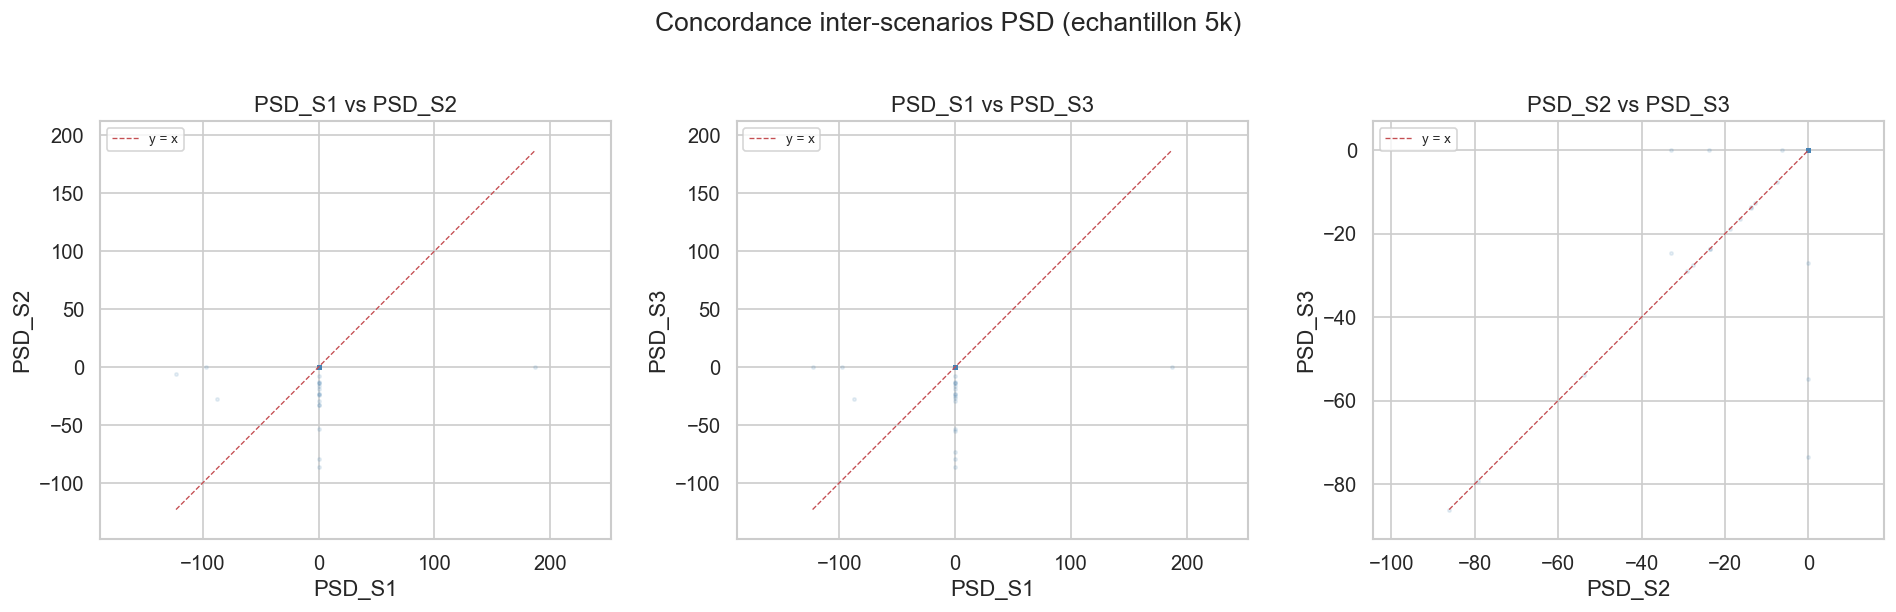

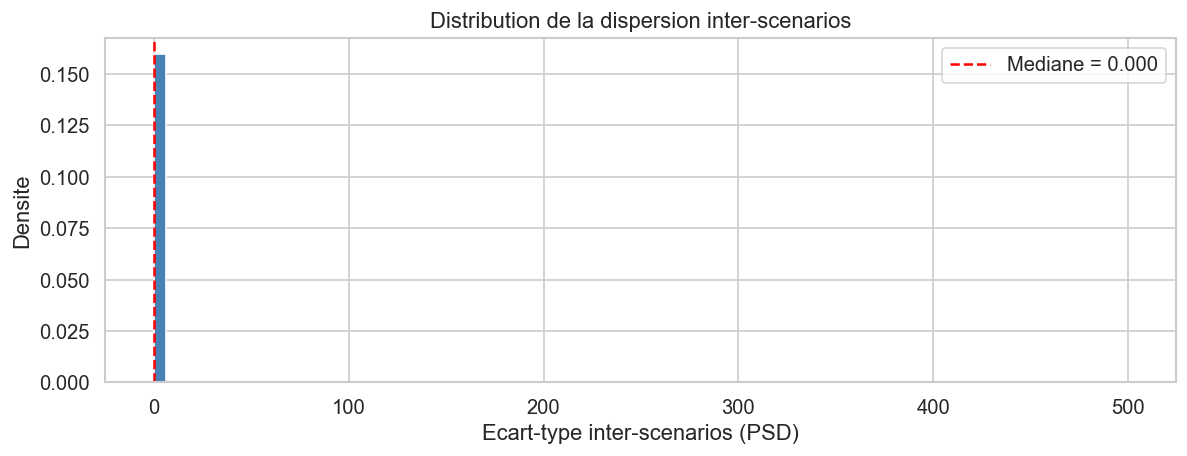

In [13]:
# --- Scatter plots: scenario pairs ---
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
pairs = [("PSD_S1", "PSD_S2"), ("PSD_S1", "PSD_S3"), ("PSD_S2", "PSD_S3")]

for i, (sa, sb) in enumerate(pairs):
    ax = axes[i]
    sub = concordance.sample(min(5000, len(concordance)), random_state=42)
    ax.scatter(sub[sa], sub[sb], alpha=0.12, s=4, color="steelblue")
    lims = [min(sub[[sa, sb]].min()), max(sub[[sa, sb]].max())]
    ax.plot(lims, lims, "r--", lw=0.8, label="y = x")
    ax.set_xlabel(sa)
    ax.set_ylabel(sb)
    ax.set_title(f"{sa} vs {sb}")
    ax.legend(fontsize=8)
    ax.set_aspect("equal", adjustable="datalim")

plt.suptitle("Concordance inter-scenarios PSD (echantillon 5k)", y=1.02)
plt.tight_layout()
plt.show()

# --- Distribution of inter-scenario std ---
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(concordance["scenario_std"], bins=80, color="steelblue", edgecolor="white", density=True)
ax.set_xlabel("Ecart-type inter-scenarios (PSD)")
ax.set_ylabel("Densite")
ax.set_title("Distribution de la dispersion inter-scenarios")
ax.axvline(concordance["scenario_std"].median(), color="red", ls="--", label=f"Mediane = {concordance['scenario_std'].median():.3f}")
ax.legend()
plt.tight_layout()
plt.show()

## 7. Structure de correlation

Matrice de correlation entre PSD, ACTIVATIONLEVEL et les variables d'impact, separee par PEAKID. Permet d'identifier quels drivers influencent le plus le prix simule.

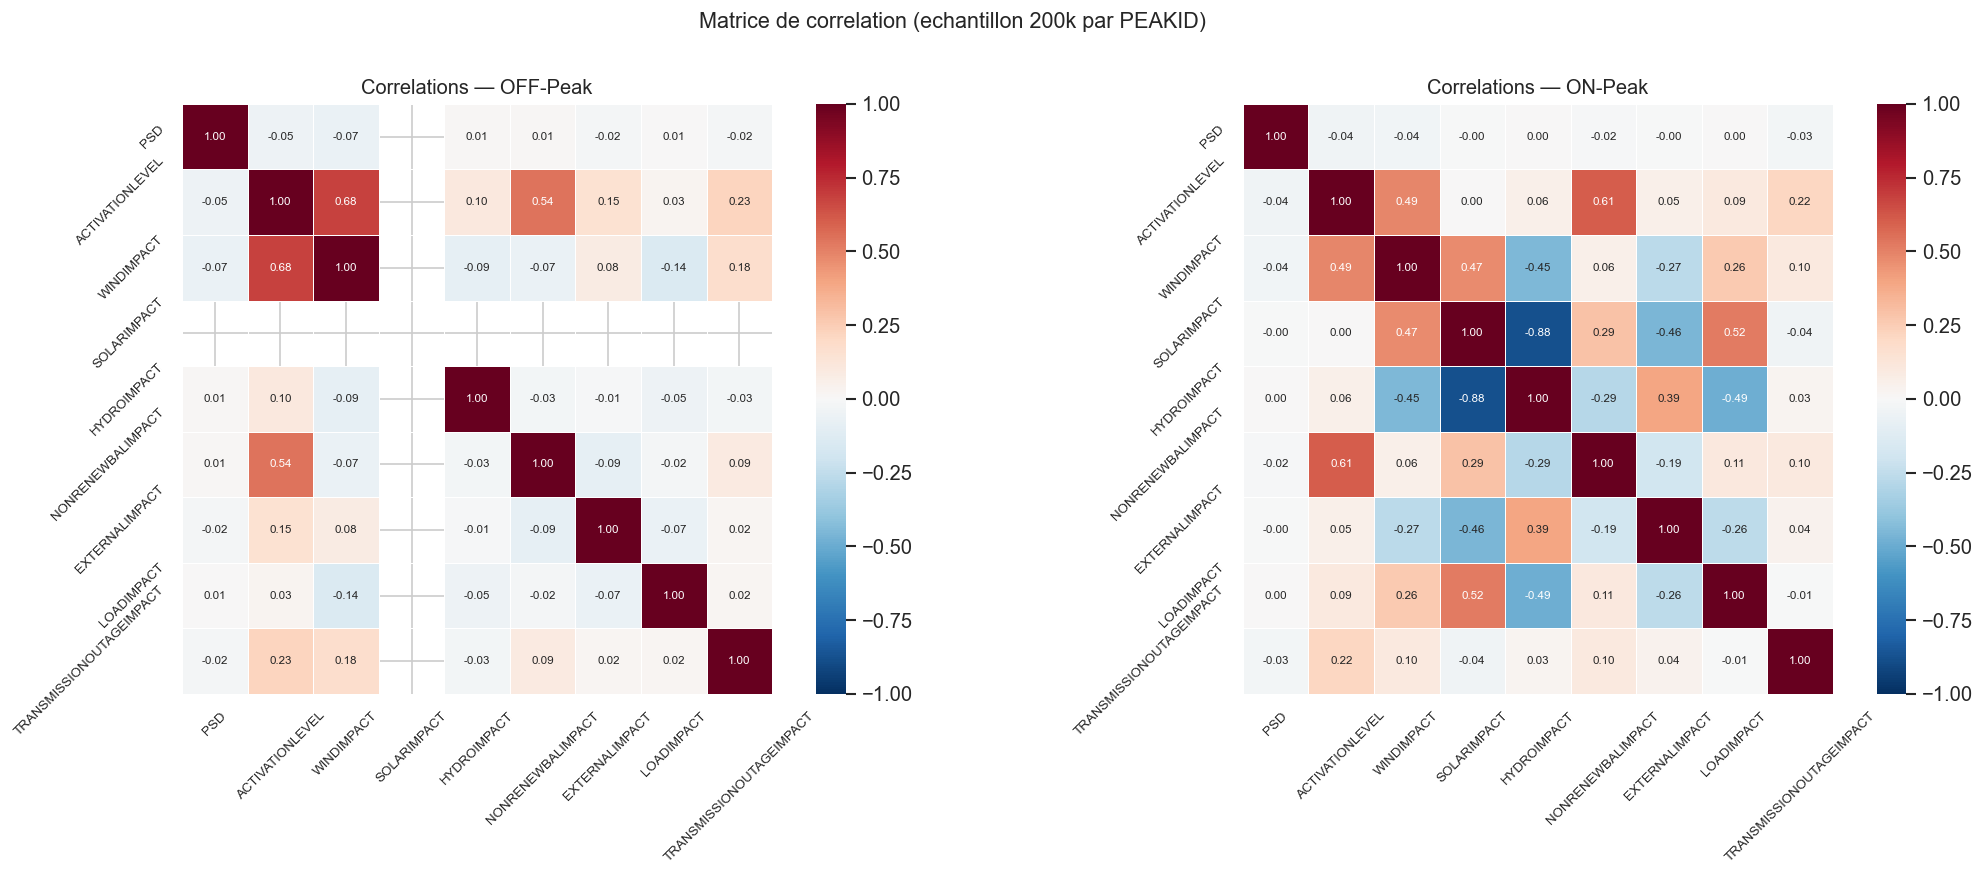

In [14]:
# --- Correlation heatmaps by PEAKID ---
corr_vars = ["PSD", "ACTIVATIONLEVEL", "WINDIMPACT", "SOLARIMPACT", "HYDROIMPACT",
             "NONRENEWBALIMPACT", "EXTERNALIMPACT", "LOADIMPACT", "TRANSMISSIONOUTAGEIMPACT"]

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
for i, peak in enumerate([0, 1]):
    sample_corr = con.execute(f"""
        SELECT {', '.join(corr_vars)}
        FROM sim_daily
        WHERE PEAKID = {peak}
        USING SAMPLE 200000
    """).fetchdf()

    corr_matrix = sample_corr.corr()
    ax = axes[i]
    sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="RdBu_r",
                center=0, vmin=-1, vmax=1, ax=ax, square=True,
                annot_kws={"fontsize": 7}, linewidths=0.5)
    ax.set_title(f"Correlations — {peak_labels[peak]}", fontsize=12)
    ax.tick_params(axis="both", labelsize=8, rotation=45)

plt.suptitle("Matrice de correlation (echantillon 200k par PEAKID)", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 8. Patterns temporels

Variation mensuelle/saisonniere du PSD et des impacts. Comparaison ete vs hiver, semaine vs weekend.

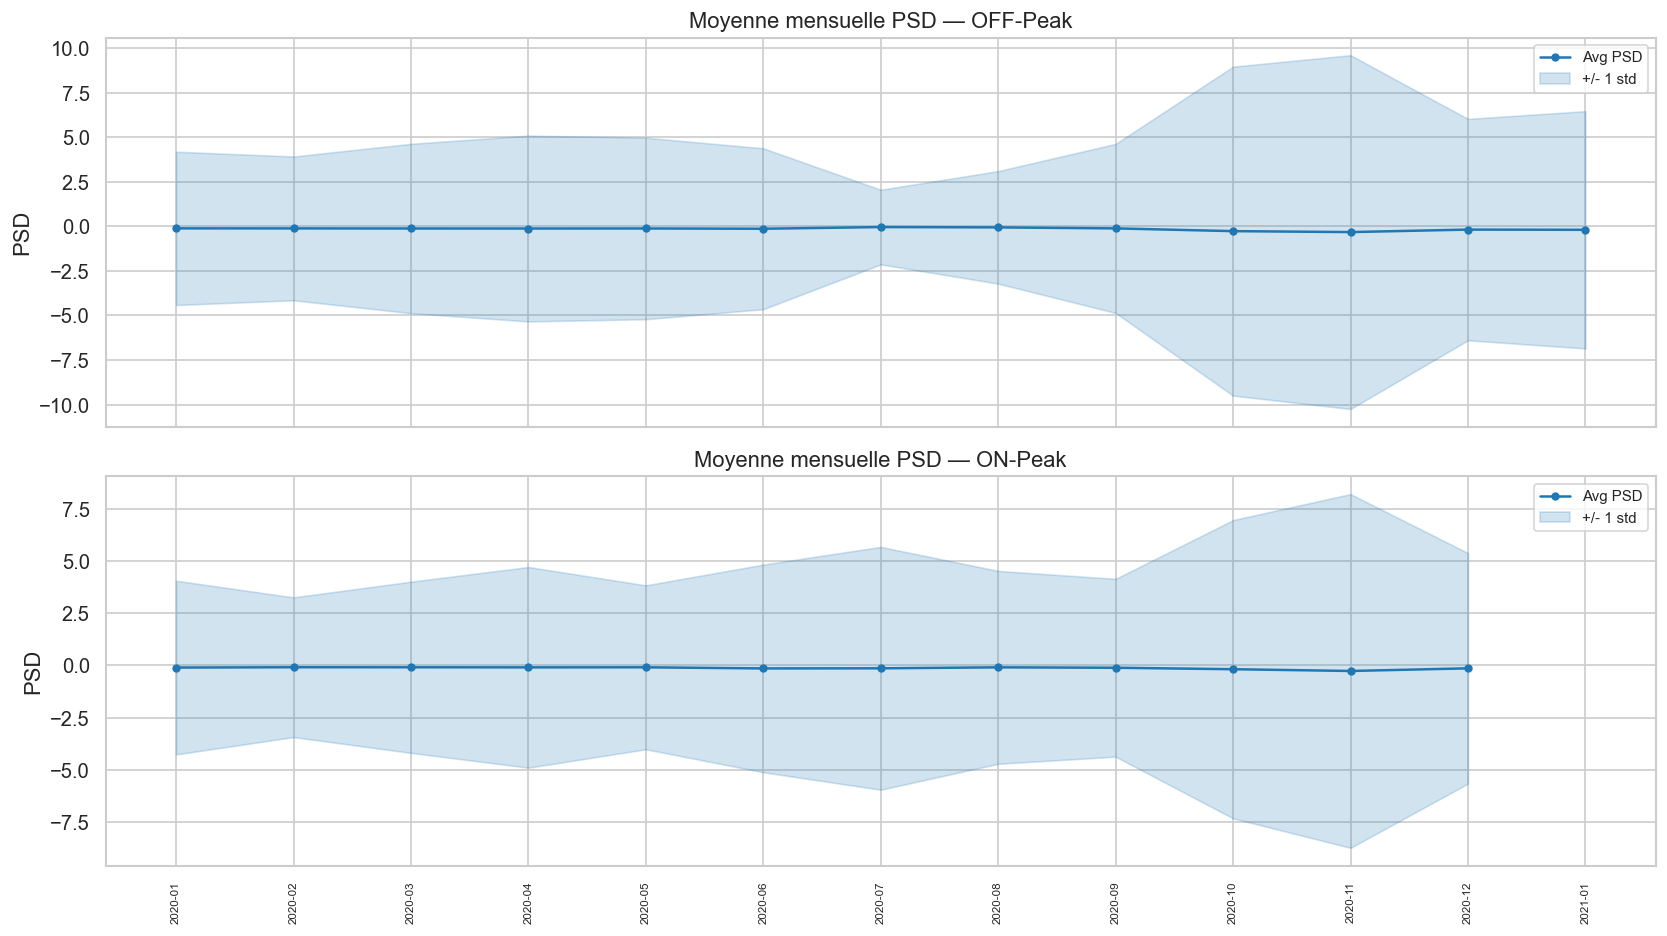

In [15]:
# --- Monthly average PSD ---
monthly_avg = con.execute("""
    SELECT YEAR, MONTH, PEAKID,
           AVG(PSD) AS avg_psd,
           STDDEV(PSD) AS std_psd,
           AVG(ACTIVATIONLEVEL) AS avg_activation
    FROM sim_daily
    GROUP BY YEAR, MONTH, PEAKID
    ORDER BY YEAR, MONTH, PEAKID
""").fetchdf()
monthly_avg["period"] = monthly_avg["YEAR"].astype(str) + "-" + monthly_avg["MONTH"].astype(str).str.zfill(2)

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
for i, peak in enumerate([0, 1]):
    ax = axes[i]
    sub = monthly_avg[monthly_avg["PEAKID"] == peak]
    ax.plot(sub["period"], sub["avg_psd"], marker="o", markersize=4, color="#1f77b4", label="Avg PSD")
    ax.fill_between(sub["period"],
                     sub["avg_psd"] - sub["std_psd"],
                     sub["avg_psd"] + sub["std_psd"],
                     alpha=0.2, color="#1f77b4", label="+/- 1 std")
    ax.set_ylabel("PSD")
    ax.set_title(f"Moyenne mensuelle PSD — {peak_labels[peak]}")
    ax.legend(fontsize=9)
    ax.tick_params(axis="x", rotation=90, labelsize=7)
plt.tight_layout()
plt.show()

DAYOFWEEK for Monday 2020-01-06: 1
Convention: 0=Sunday, 6=Saturday → weekend IN (0, 6)

=== PSD PAR SAISON / TYPE DE JOUR / PEAKID ===
  season day_type  PEAKID  avg_psd  std_psd  avg_activation   n_rows
Shoulder  Weekday       0  -0.1691   6.6904          7.5398 14598186
Shoulder  Weekday       1  -0.1339   5.4456          7.8659 29196960
Shoulder  Weekend       0  -0.2050   7.4442          7.5779  5964882
Shoulder  Weekend       1  -0.1697   6.4883          7.8486 11931936
  Summer  Weekday       0  -0.0774   3.5321          8.4404  7343424
  Summer  Weekday       1  -0.1348   5.4478          9.2743 14686848
  Summer  Weekend       0  -0.0727   2.9913          8.4292  2892864
  Summer  Weekend       1  -0.1118   4.3521          9.1124  5785728
  Winter  Weekday       0  -0.1381   5.1215          7.9901  7532196
  Winter  Weekday       1  -0.1272   4.8419          8.2128 15061632
  Winter  Weekend       0  -0.1398   4.7737          8.0708  2844912
  Winter  Weekend       1  -0.0840  

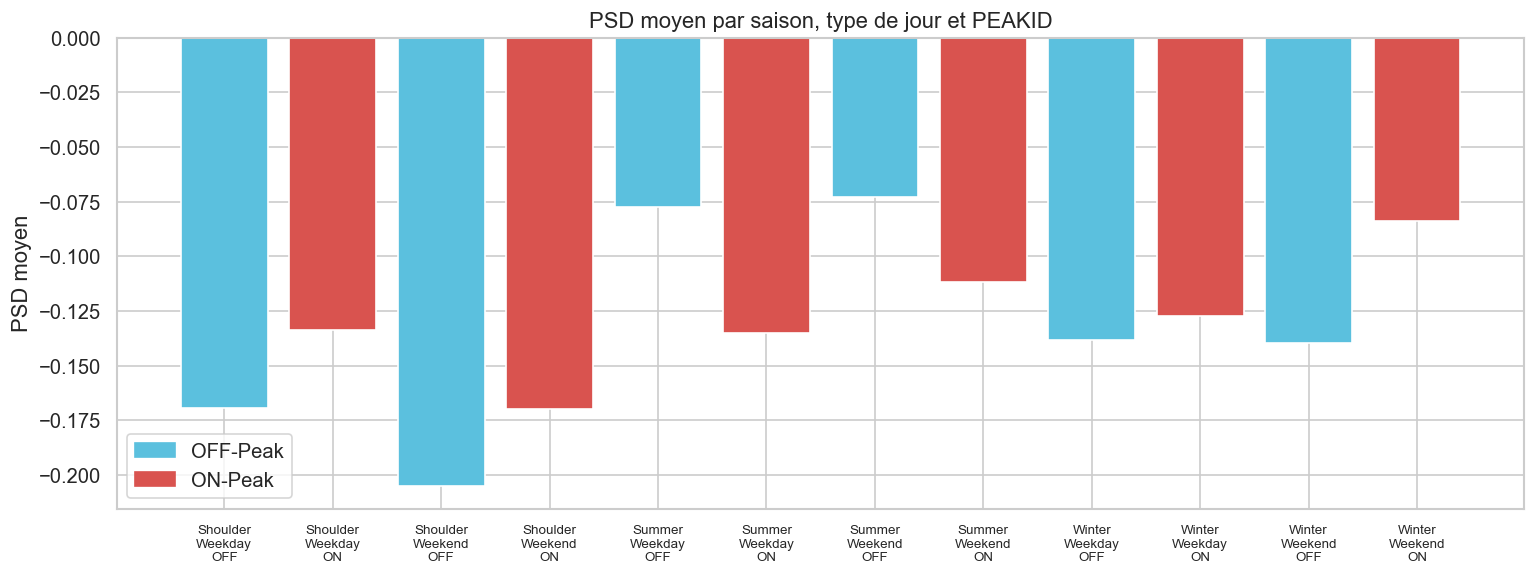

In [16]:
# --- Seasonality: summer vs winter, weekday vs weekend ---
# Note: DuckDB DAYOFWEEK returns 0=Sunday, 6=Saturday (ISO: 0=Monday in some versions)
# We verify first:
dow_check = con.execute("""
    SELECT DATETIME, DAYOFWEEK(DATETIME) AS dow
    FROM sim_daily
    WHERE DATETIME = '2020-01-06 12:00:00'  -- Monday Jan 6, 2020
    LIMIT 1
""").fetchdf()
monday_dow = dow_check["dow"].iloc[0] if len(dow_check) > 0 else None
print(f"DAYOFWEEK for Monday 2020-01-06: {monday_dow}")

# Build weekend condition based on actual DuckDB behavior
if monday_dow == 1:  # ISO: 0=Sunday or 1=Monday
    weekend_cond = "DAYOFWEEK(DATETIME) IN (0, 6)"  # Sun=0, Sat=6
    print("Convention: 0=Sunday, 6=Saturday → weekend IN (0, 6)")
else:
    weekend_cond = "DAYOFWEEK(DATETIME) IN (5, 6)"  # Sat=5, Sun=6
    print(f"Convention detectee: Monday={monday_dow} → ajustement weekend")

seasonal = con.execute(f"""
    SELECT
        CASE WHEN MONTH IN (6,7,8) THEN 'Summer'
             WHEN MONTH IN (12,1,2) THEN 'Winter'
             ELSE 'Shoulder' END AS season,
        CASE WHEN {weekend_cond} THEN 'Weekend'
             ELSE 'Weekday' END AS day_type,
        PEAKID,
        AVG(PSD) AS avg_psd,
        STDDEV(PSD) AS std_psd,
        AVG(ACTIVATIONLEVEL) AS avg_activation,
        COUNT(*) AS n_rows
    FROM sim_daily
    GROUP BY season, day_type, PEAKID
    ORDER BY season, day_type, PEAKID
""").fetchdf()

print("\n=== PSD PAR SAISON / TYPE DE JOUR / PEAKID ===")
print(seasonal.to_string(index=False, float_format="%.4f"))

# Bar chart
fig, ax = plt.subplots(figsize=(13, 5))
seasonal["label"] = seasonal["season"] + "\n" + seasonal["day_type"] + "\n" + seasonal["PEAKID"].map({0: "OFF", 1: "ON"})
bar_colors = seasonal["PEAKID"].map({0: "#5bc0de", 1: "#d9534f"})
ax.bar(range(len(seasonal)), seasonal["avg_psd"], color=bar_colors, edgecolor="white")
ax.set_xticks(range(len(seasonal)))
ax.set_xticklabels(seasonal["label"], fontsize=8)
ax.set_ylabel("PSD moyen")
ax.set_title("PSD moyen par saison, type de jour et PEAKID")

# Add legend
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color="#5bc0de", label="OFF-Peak"), Patch(color="#d9534f", label="ON-Peak")])
plt.tight_layout()
plt.show()

## 9. Synthese

### Findings cles
*(A completer apres execution du notebook — les points ci-dessous sont les axes a renseigner)*

1. **Dimensions** : X lignes, Y EIDs distincts, 3 scenarios, 2 PEAKIDs, granularite horaire
2. **Couverture temporelle** : les sims daily couvrent tous les jours du mois courant (convention HE confirmee)
3. **Sparsity** : certaines variables (ex: SOLARIMPACT la nuit) sont tres creuses — a traiter dans le feature engineering
4. **Distributions** : PSD centre autour de 0 avec queues lourdes — les opportunites profitables sont dans les queues
5. **Concordance** : les 3 scenarios sont [correlees/divergentes] — la dispersion inter-scenario est un signal d'incertitude
6. **Correlations** : [identifier les drivers principaux de PSD par PEAKID]
7. **Patterns temporels** : saisonnalite marquee (hiver > ete pour PSD), difference semaine/weekend

### Implications pour le modele
- Les daily sims couvrent le mois entier mais **seuls les jours 1-7 de M sont utilisables au cutoff**
- La dispersion inter-scenario est une feature de premier ordre (signal d'incertitude)
- Les patterns saisonniers suggerent d'inclure le mois comme feature categorielle

In [ ]:
# --- Recommended features for modeling ---
print("""
FEATURES RECOMMANDEES DEPUIS sim_daily
(calculees sur les jours 1-7 du mois M, par EID et PEAKID)
========================================================

Agregations de base :
  1. PSD_mean_7d         — Moyenne PSD sur jours 1-7 (moyenne des 3 scenarios)
  2. PSD_sum_7d          — Somme PSD sur jours 1-7 (par scenario, puis moyenne)
  3. ACTIVATION_mean_7d  — Moyenne ACTIVATIONLEVEL sur jours 1-7

Signaux d'incertitude :
  4. PSD_std_scenario    — Ecart-type PSD entre les 3 scenarios (par heure, puis moyenne)
  5. PSD_range_scenario  — Max - Min PSD entre scenarios
  6. PSD_std_temporal    — Ecart-type PSD au fil des jours 1-7 (volatilite temporelle)

Tendance :
  7. PSD_trend_slope     — Pente lineaire du PSD moyen journalier sur jours 1-7
  8. PSD_early_vs_late   — Ratio PSD moyen jours 1-3 vs jours 4-7

Impacts dominants :
  9. dominant_impact     — Variable d'impact avec la plus grande valeur absolue moyenne
 10. WIND_mean_7d        — Moyenne WINDIMPACT (si identifie comme driver dans la correlation)
 11. SOLAR_mean_7d       — Moyenne SOLARIMPACT

Contexte :
 12. target_month        — Mois cible M+1 (feature categorielle)
 13. n_hours_available   — Nombre d'heures disponibles dans les jours 1-7
""")

# Cleanup
con.close()
print("Connexion DuckDB fermee.")